## Example: 2D simulation of Taylor Green Vortex using Lattice Boltzmann Method


The example solves the Naiver Stokes Equation using Lattice Boltzmann Method. Here we setup the problem using an analytical solution of N-S equation: Taylor Green Vortex. Its velocity field and pressure field can be written as


$$u= -u_{\max} \cos \frac{2\pi x}{L} \sin \frac{2\pi y}{L} e^{-\nu t} $$ 

$$ v=u_{\max}\sin \frac{2\pi x}{L} \cos \frac{2\pi y}{L} e^{-\nu t} $$

$$p= -\frac {1}{4}  \rho_0 u_{\max}^2 ( \cos \frac{2\pi x}{L} + \cos \frac{2\pi y}{L} ) e^{-2\nu t} $$

Here, the Boltzmann equation is written as

$$\frac{\partial f}{\partial t}+ \xi_\alpha \frac{\partial f}{\partial x_\alpha} +\frac{f_\alpha}{\rho}\frac{\partial f}{\partial \xi_\alpha}=\Omega(f),$$

where the probability density function $f(\mathbf{x},\mathbf{\xi}, t)$, which is defined as a function of location $\mathbf{x}$, microscopic particle velocity $\mathbf{\xi}$, and time $t$. $f_\alpha$ is external forcing, and $\Omega(f)$ is the collision term.

The problem is solved in 2D using D2Q9 discretization, and the collision term is solved using BGK operator.


## Running the code

The simulation can be ran as `./mained.gnu.ex inputs`. 

The following inputs parameters could be tweaked:

```
scale = 2              # scale of the problem
max_grid_size = 64                # max grid size used for domain decomposition
Nx = 32    # size of the domain in both directions are Nx*scale
NSTEP=200  # number of time steps is NSTEP*scale*scale
plot_int=50 # interval of saving data, if not save, then set as -1
```


## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset

/tmp/ipykernel_129801/3074286631.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


yt : [INFO     ] 2025-05-04 11:58:23,650 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 11:58:23,651 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 11:58:23,652 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 11:58:23,652 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 11:58:23,971 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:23,972 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:23,973 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:23,974 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:23,976 Making a fixed resolution buffer of (('boxlib', 'vor')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]



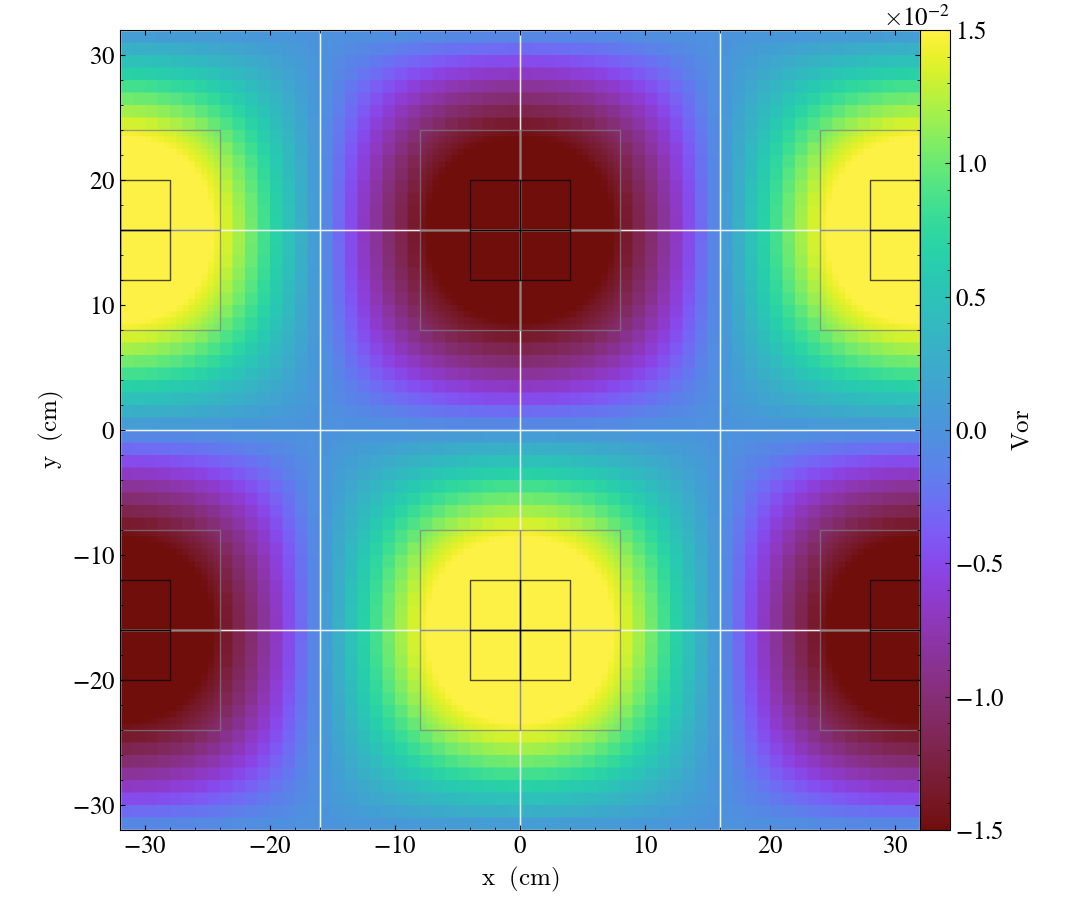

In [2]:
ds = AMReXDataset("plt00000")
print("Available fields:", ds.field_list)
field = ("boxlib", "vor" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -1.5*10**(-2), 1.5*10**(-2))

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

yt : [INFO     ] 2025-05-04 11:58:24,520 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 11:58:24,520 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 11:58:24,521 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 11:58:24,521 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 11:58:24,658 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:24,659 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:24,660 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:24,660 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 11:58:24,662 Making a fixed resolution buffer of (('boxlib', 'vor')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]



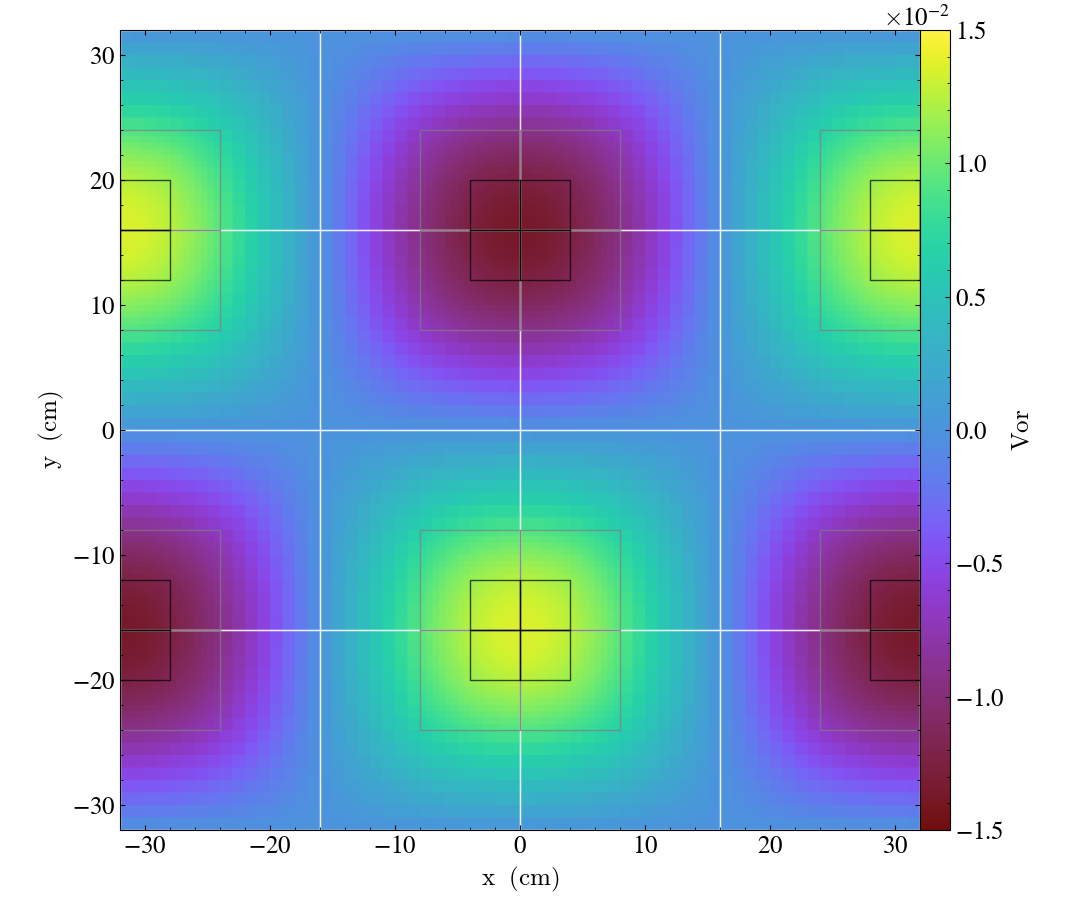

In [3]:
ds = AMReXDataset("plt00150")
print("Available fields:", ds.field_list)
field = ("boxlib", "vor" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -1.5*10**(-2), 1.5*10**(-2))

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

## Validation of the results using analytical solution

yt : [INFO     ] 2025-05-04 12:12:11,989 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 12:12:11,989 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:12:11,990 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:12:11,991 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 12:12:12,261 Parameters: current_time              = 50.0
yt : [INFO     ] 2025-05-04 12:12:12,262 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:12:12,263 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:12:12,263 Parameters: domain_right_edge         = [64. 64.  1.]


t=0.000 code_time: err_ux=0.000e+00, err_uy=0.000e+00, err_rho=0.000e+00


yt : [INFO     ] 2025-05-04 12:12:12,510 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-05-04 12:12:12,512 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:12:12,513 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:12:12,514 Parameters: domain_right_edge         = [64. 64.  1.]


t=50.000 code_time: err_ux=2.287e-02, err_uy=2.802e-02, err_rho=7.577e-01


yt : [INFO     ] 2025-05-04 12:12:12,937 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 12:12:12,938 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:12:12,939 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:12:12,940 Parameters: domain_right_edge         = [64. 64.  1.]


...

t=750.000 code_time: err_ux=4.048e-01, err_uy=4.076e-01, err_rho=1.169e+01


yt : [INFO     ] 2025-05-04 12:12:17,872 Parameters: current_time              = 850.0
yt : [INFO     ] 2025-05-04 12:12:17,873 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:12:17,873 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:12:17,874 Parameters: domain_right_edge         = [64. 64.  1.]


t=800.000 code_time: err_ux=4.443e-01, err_uy=4.327e-01, err_rho=4.902e+00


yt : [INFO     ] 2025-05-04 12:12:18,136 Parameters: current_time              = 900.0
yt : [INFO     ] 2025-05-04 12:12:18,137 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:12:18,138 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:12:18,139 Parameters: domain_right_edge         = [64. 64.  1.]


t=850.000 code_time: err_ux=4.660e-01, err_uy=4.776e-01, err_rho=6.688e+00
t=900.000 code_time: err_ux=5.081e-01, err_uy=5.036e-01, err_rho=1.979e+01


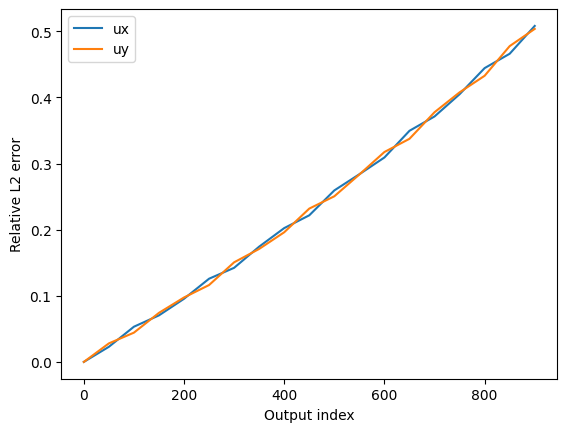

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import yt

L     = 64.0
u_max = 0.02
rho0  = 1.0
kx, ky= 2*np.pi/L, 2*np.pi/L
nu    = 1.0/6.0
td    = 1.0/(nu*(kx*kx+ky*ky))

def u_exact(x,y,z,t):
    decay1 = np.exp(-1.0*t/td)
    decay2 = np.exp(-2.0*t/td)
    ux = -u_max*np.sqrt(ky/kx)*np.cos(kx*x)*np.sin(ky*y)*decay1
    uy =  u_max*np.sqrt(kx/ky)*np.sin(kx*x)*np.cos(ky*y)*decay1
    P  = -0.25*rho0*u_max**2*((ky/kx)*np.cos(2*kx*x)
                             + (kx/ky)*np.cos(2*ky*y))*decay2
    rho= rho0 + 3.0*P
    return ux, uy, rho

times = np.arange(0,950,50)
err_ux, err_uy, err_rho = [], [], []

for idx in times:
    ds = yt.load(f"plt{idx:05d}")
    t_phys = ds.current_time

    # —— use all_data() to grab every AMR level at once ——
    ad = ds.all_data()
    x = ad[("index","x")].v
    y = ad[("index","y")].v
    z = ad[("index","z")].v
    vol = ad[("index","cell_volume")].v

    ux_num = ad[("boxlib","ux")].v
    uy_num = ad[("boxlib","uy")].v
    rho_num= ad[("boxlib","rho")].v

    ux_ex, uy_ex, rho_ex = u_exact(x,y,z,t_phys)

    dux = ux_num - ux_ex
    duy = uy_num - uy_ex
    drho= rho_num- rho_ex

    # relative L2 norm, volume-weighted:
    def rel_L2(e, ref):
        return np.sqrt(np.sum(e*e*vol) / np.sum(ref*ref*vol))

    err_ux.append(rel_L2(dux, ux_ex))
    err_uy.append(rel_L2(duy, uy_ex))
    # for density subtract background if desired
    err_rho.append(rel_L2(drho, rho_ex - rho0))

    print(f"t={t_phys:.3f}: err_ux={err_ux[-1]:.3e}, "
          f"err_uy={err_uy[-1]:.3e}, err_rho={err_rho[-1]:.3e}")

# plot the time evolution of the errors
plt.plot(times, err_ux, label='ux')
plt.plot(times, err_uy, label='uy')
# plt.plot(times, err_rho,label='rho')
plt.xlabel('Output index')
plt.ylabel('Relative L2 error')
plt.legend()
plt.show()
